# Регрессия
### Задача
Предсказать время доставки товара

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Загружаем таблицы

In [17]:
orders = pd.read_csv("../dataset/olist_orders_dataset.csv")
order_items = pd.read_csv("../dataset/olist_order_items_dataset.csv")
products = pd.read_csv("../dataset/olist_products_dataset.csv")
sellers = pd.read_csv("../dataset/olist_sellers_dataset.csv")
customers = pd.read_csv("../dataset/olist_customers_dataset.csv")
reviews = pd.read_csv("../dataset/olist_order_reviews_dataset.csv")
payments = pd.read_csv("../dataset/olist_order_payments_dataset.csv")
geolocation = pd.read_csv("../dataset/olist_geolocation_dataset.csv")

Объединяем таблицы

In [18]:
df = orders.merge(order_items, on="order_id", how="left")
df = df.merge(products, on="product_id", how="left")
df = df.merge(reviews[["order_id", "review_score"]], on="order_id", how="left")
payment_agg = payments.groupby("order_id")["payment_value"].sum().reset_index()
df = df.merge(payment_agg, on="order_id", how="left")

Создание целевого признака delivery_time_days

In [19]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])
df["order_delivered_customer_date"] = pd.to_datetime(df["order_delivered_customer_date"])

df["delivery_time_days"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.days

In [20]:
df = df[df["delivery_time_days"].notna()]
df = df[df["delivery_time_days"] > 0]

Визуализация признака target

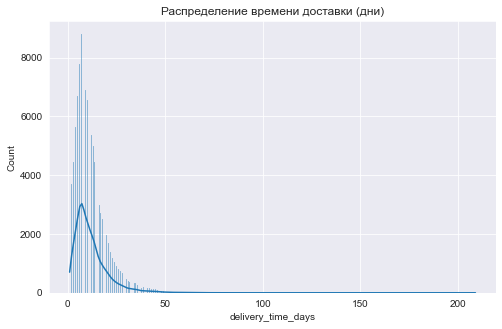

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df["delivery_time_days"], kde=True)
plt.title("Распределение времени доставки (дни)")
plt.show()

Создание признаков и агрегация

In [22]:
df["product_volume_cm3"] = (
    df["product_length_cm"] * df["product_height_cm"] * df["product_width_cm"]
)

df["product_density"] = df["product_weight_g"] / df["product_volume_cm3"]

In [23]:
order_items_agg = order_items.groupby("order_id").agg(
    avg_price=("price", "mean"),
    avg_freight=("freight_value", "mean"),
    num_items=("order_item_id", "count")
).reset_index()
df = df.merge(order_items_agg, on="order_id", how="left")

In [24]:
order_price_agg = order_items.groupby("order_id")["price"].sum().reset_index()
df = df.merge(order_price_agg, on="order_id", how="left", suffixes=("", "_total"))

In [25]:
geo_agg = geolocation.groupby("geolocation_zip_code_prefix").agg(
    geo_lat=("geolocation_lat", "mean"),
    geo_lng=("geolocation_lng", "mean")
).reset_index()

In [26]:
df = df.merge(customers[["customer_id", "customer_zip_code_prefix"]], on="customer_id", how="left")
df = df.merge(
    geo_agg,
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)

Обработка пропусков

In [27]:
df = df.dropna(subset=[
    "product_weight_g", "product_volume_cm3",
    "product_length_cm", "product_height_cm", "product_width_cm"
])
df = df.dropna(subset=["geo_lat", "geo_lng"])

Обработка выбросов

In [28]:
def clip_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return series.clip(lower, upper)

df["delivery_time_days"] = clip_outliers(df["delivery_time_days"])
df["price_total"] = clip_outliers(df["price_total"])
df["product_weight_g"] = clip_outliers(df["product_weight_g"])
df["product_density"] = clip_outliers(df["product_density"])

Формирование итогового набора признаков

In [29]:
features = [
    "avg_price",
    "avg_freight",
    "num_items",
    "geo_lat",
    "geo_lng",
    "product_weight_g",
    "product_volume_cm3",
    "product_density",
    "payment_value",
    "review_score"
]
df_model = df[features + ["delivery_time_days"]].dropna()

Визуализация значимых признаков

Гистограммы признаков

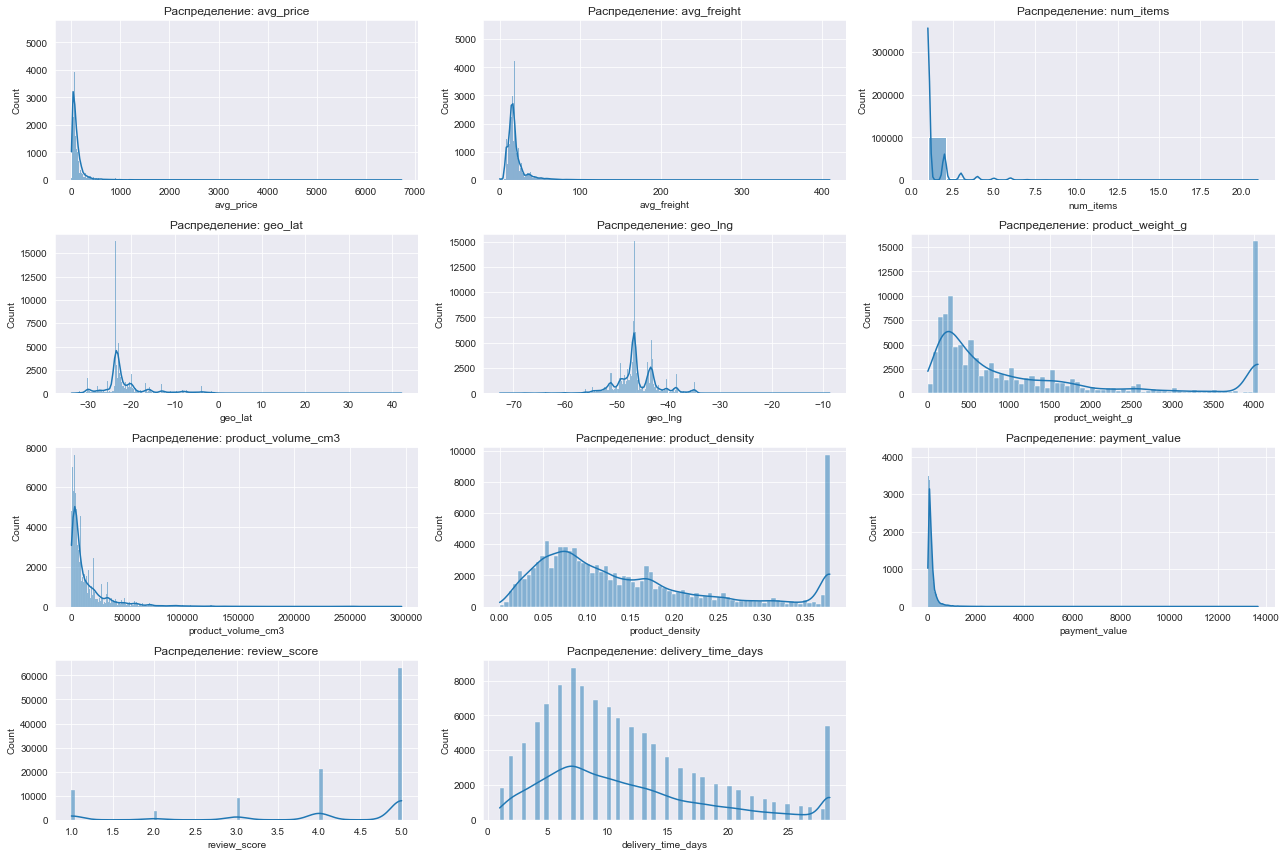

In [30]:
plt.figure(figsize=(18, 12))

for i, col in enumerate(features + ["delivery_time_days"]):
    plt.subplot(4, 3, i+1)
    sns.histplot(df_model[col], kde=True)
    plt.title(f"Распределение: {col}")

plt.tight_layout()
plt.show()

Boxplot

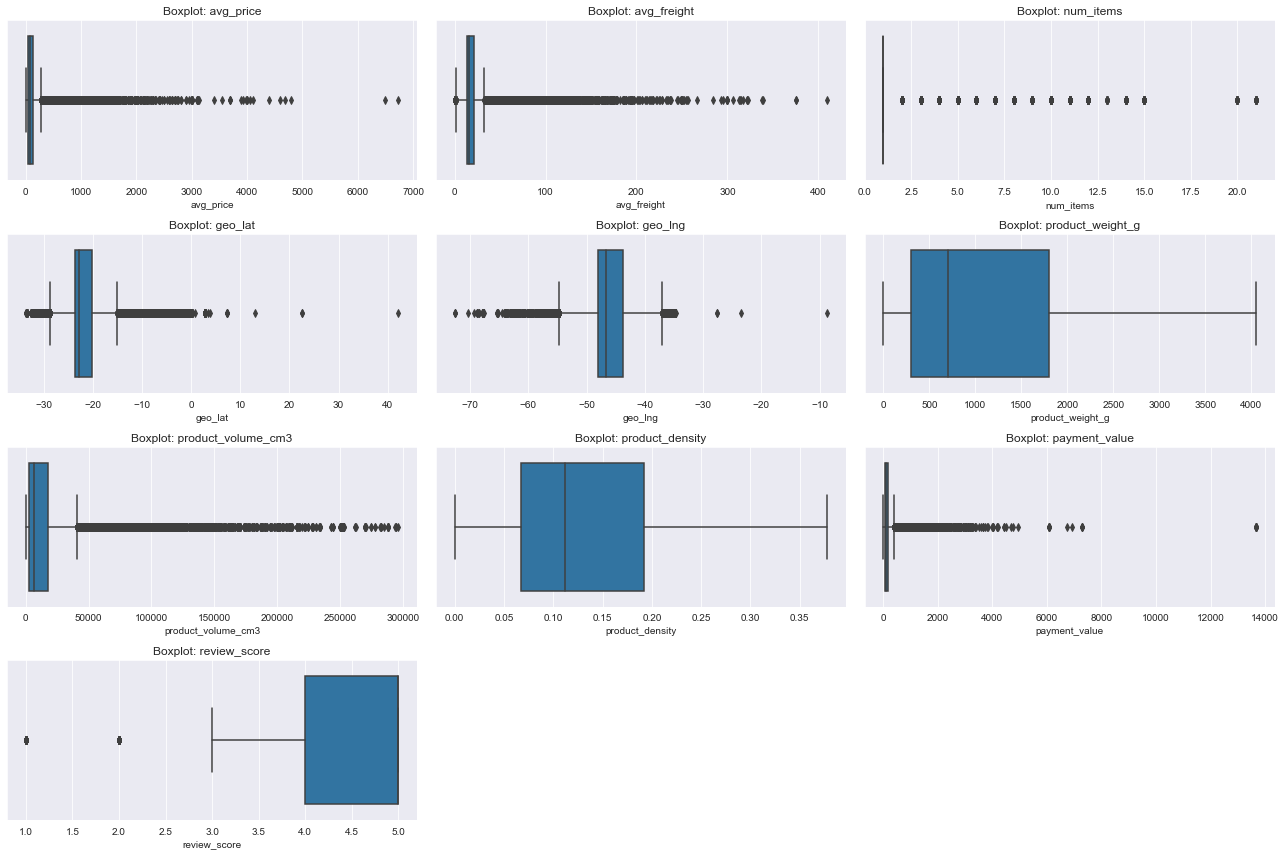

In [31]:
plt.figure(figsize=(18, 12))

for i, col in enumerate(features):
    plt.subplot(4, 3, i+1)
    sns.boxplot(x=df_model[col])
    plt.title(f"Boxplot: {col}")

plt.tight_layout()
plt.show()

Scatterplot

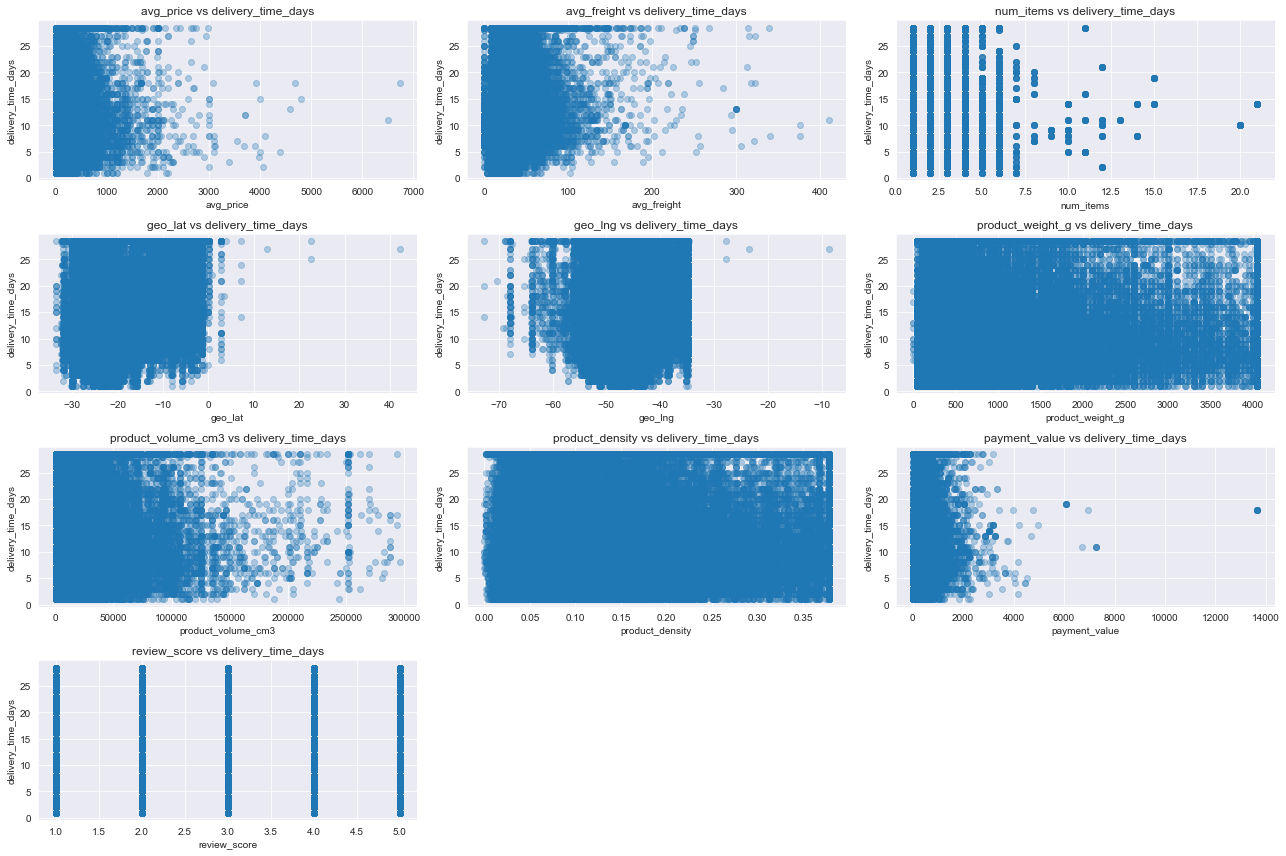

In [32]:
plt.figure(figsize=(18, 12))

for i, col in enumerate(features):
    plt.subplot(4, 3, i+1)
    plt.scatter(df_model[col], df_model["delivery_time_days"], alpha=0.3)
    plt.xlabel(col)
    plt.ylabel("delivery_time_days")
    plt.title(f"{col} vs delivery_time_days")

plt.tight_layout()
plt.show()

Корреляционная матрица

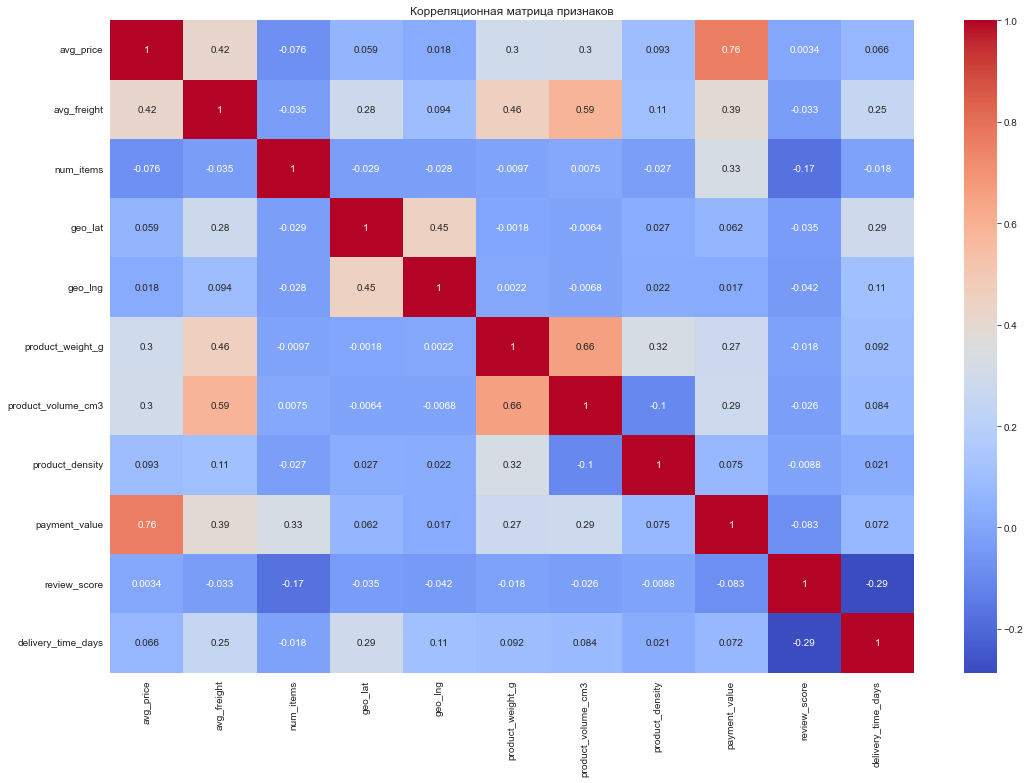

In [33]:
plt.figure(figsize=(18, 12))
sns.heatmap(df_model[features + ["delivery_time_days"]].corr(), annot=True, cmap="coolwarm")
plt.title("Корреляционная матрица признаков")
plt.show()

Разделение данных

In [34]:
X = df_model[features]
y = df_model["delivery_time_days"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Стандартизация

In [35]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Linear Regression

In [36]:
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

### Lasso

In [37]:
lasso_params = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1, 5, 10]
}

In [38]:
from sklearn.model_selection import GridSearchCV


lasso = Lasso(max_iter=5000)

lasso_grid = GridSearchCV(
    lasso,
    lasso_params,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

best_lasso = lasso_grid.best_estimator_
pred_lasso = best_lasso.predict(X_test)
print(lasso_grid.best_params_)

{'alpha': 0.0001}


### Ridge

In [39]:
ridge_params = {
    "alpha": [0.01, 0.1, 1, 5, 10, 20, 50, 100]
}

In [40]:
ridge = Ridge(max_iter=5000)

ridge_grid = GridSearchCV(
    ridge,
    ridge_params,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

best_ridge = ridge_grid.best_estimator_
pred_ridge = best_ridge.predict(X_test)
print(ridge_grid.best_params_)

{'alpha': 0.01}


Метрики и сравнение моделей

In [41]:
def evaluate_model(y_true, y_pred, name):
    print(f"\n===  {name}  ===")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))
    print("R2:", r2_score(y_true, y_pred))

In [42]:
evaluate_model(y_test, pred_lr, "Linear Regression")
evaluate_model(y_test, pred_lasso, "LASSO")
evaluate_model(y_test, pred_ridge, "Ridge Regression")


===  Linear Regression  ===
MAE: 5.037494694736801
MSE: 39.96307135533184
RMSE: 6.321635180499729
R2: 0.1978122824865416

===  LASSO  ===
MAE: 5.03750645405769
MSE: 39.96311447144797
RMSE: 6.321638590701621
R2: 0.1978114170070473

===  Ridge Regression  ===
MAE: 5.0374947231898695
MSE: 39.96307138493784
RMSE: 6.32163518284137
R2: 0.19781228189225375


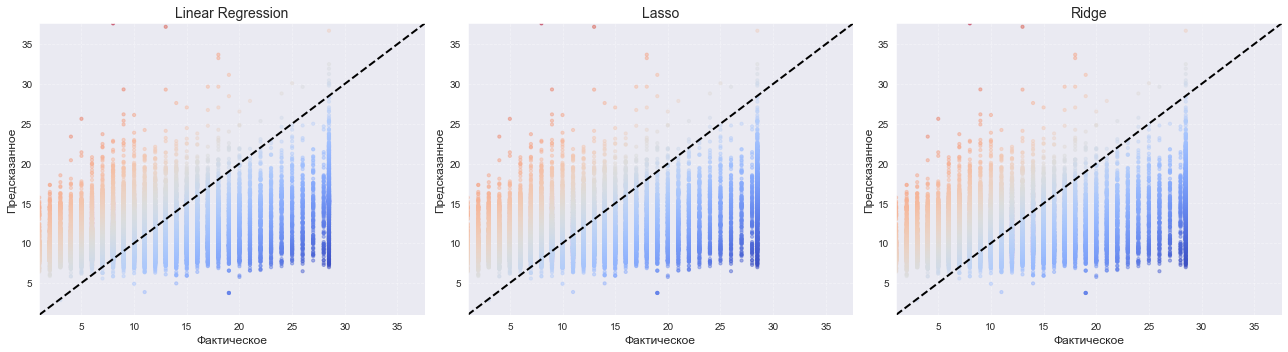

In [43]:
plt.figure(figsize=(18, 5))

models = [
    ("Linear Regression", pred_lr),
    ("Lasso", pred_lasso),
    ("Ridge", pred_ridge)
]

for i, (name, pred) in enumerate(models, 1):
    plt.subplot(1, 3, i)

    errors = pred - y_test

    plt.scatter(
        y_test, pred,
        c=errors, cmap="coolwarm",
        alpha=0.45, s=10
    )

    min_val = min(y_test.min(), pred.min())
    max_val = max(y_test.max(), pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2)

    plt.title(name, fontsize=14)
    plt.xlabel("Фактическое", fontsize=12)
    plt.ylabel("Предсказанное", fontsize=12)

    plt.grid(True, linestyle="--", alpha=0.4)
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)

plt.tight_layout()
plt.show()
